In [5]:
"""plot average sign and loss as heatmap."""
import numpy as np  # noqa
# import os  # noqa
# import matplotlib.gridspec as gridspec  # noqa
import matplotlib.pyplot as plt  # noqa
import pandas as pd  # noqa
import itertools  # noqa
from mpl_toolkits.axes_grid1 import make_axes_locatable
# import pandas  # noqa

import sys  # noqa
from pathlib import Path  # noqa
PYTHON_DIR = Path("/home/keisuke/worms/python" )
sys.path.insert(0, PYTHON_DIR.resolve().as_posix())
print(sys.path)
from rmsKit import utils  # noqa
logger = utils.get_logger("log.log", level="INFO", stdout=True)

IMAGE_PATH = PYTHON_DIR / "visualize" / "image"
WORM_RESULT_PATH = PYTHON_DIR / "rmsKit" / "array" / "torch"

model_name = "SS2D"
image_model_dir = IMAGE_PATH / model_name
worm_result_path = WORM_RESULT_PATH / (model_name+"_loc")

N = 10**5
BETA_THRES = 20

if not IMAGE_PATH.exists():
    raise FileNotFoundError("{} does not exist.".format(IMAGE_PATH.resolve()))
if not WORM_RESULT_PATH.exists():
    raise FileNotFoundError("{} does not exist.".format(WORM_RESULT_PATH.resolve()))
if not worm_result_path.exists():
    raise FileNotFoundError("{} does not exist.".format(worm_result_path.resolve()))

summary_files = utils.path.find_summary_files(worm_result_path)
df = utils.path.get_df_from_summary_files(summary_files, N)


['/home/keisuke/worms/python', '/home/keisuke/worms/python', '/opt/materiapps/intel/boost/boost-1.82.0-1/lib/python', '/opt/intel/oneapi/advisor/2024.2/pythonapi', '/home/keisuke/miniconda3/envs/py311/lib/python311.zip', '/home/keisuke/miniconda3/envs/py311/lib/python3.11', '/home/keisuke/miniconda3/envs/py311/lib/python3.11/lib-dynload', '', '/home/keisuke/.local/lib/python3.11/site-packages', '/home/keisuke/miniconda3/envs/py311/lib/python3.11/site-packages']
06.06 23:40 -- INFO   Log file will be saved to log.log


In [6]:
params_df = utils.param_dict_normalize(df['ham_path'].apply(utils.extract_parameters_from_path))
df = pd.concat([df, params_df], axis=1)

In [7]:
df

,model_name,alpha,T,bc,n_sites,u_path,ham_path,sweeps,as,as_error,...,c_error,m,m_error,chi,chi_error,loss_func,init_loss,J0,J1,J2
0,SS2D,0.1,1.0,pbc,16,NaN,/home/keisuke/worms/python/rmsKit/array/torch/...,100000,1.00000,0.000000,...,0.046518,0.0,0.0,0.0,0.0,-1_none,0.000000,1.0,1.8,1.8
1,SS2D,0.1,1.0,pbc,16,NaN,/home/keisuke/worms/python/rmsKit/array/torch/...,100000,1.00000,0.000000,...,0.047943,0.0,0.0,0.0,0.0,-1_none,0.000000,1.0,1.8,1.8
2,SS2D,0.1,1.0,pbc,16,NaN,/home/keisuke/worms/python/rmsKit/array/torch/...,100000,0.00080,0.003901,...,5452.640000,0.0,0.0,0.0,0.0,1_mel,0.354522,1.0,1.8,1.8
3,SS2D,0.1,1.0,pbc,16,NaN,/home/keisuke/worms/python/rmsKit/array/torch/...,100000,0.00586,0.003675,...,9.665840,0.0,0.0,0.0,0.0,1_mel,0.354522,1.0,1.8,1.8
4,SS2D,0.1,1.0,pbc,16,NaN,/home/keisuke/worms/python/rmsKit/array/torch/...,100000,0.09768,0.004103,...,0.344502,0.0,0.0,0.0,0.0,-1_none,0.418110,1.0,1.8,0.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1759,SS2D,0.1,1.0,pbc,16,NaN,/home/keisuke/worms/python/rmsKit/array/torch/...,100000,0.00060,0.003648,...,652.494000,0.0,0.0,0.0,0.0,1_mel,0.352850,1.0,1.9,2.0
1760,SS2D,0.1,1.0,pbc,16,NaN,/home/keisuke/worms/python/rmsKit/array/torch/...,100000,0.98944,0.000601,...,0.049435,0.0,0.0,0.0,0.0,-1_none,0.001826,1.0,2.0,1.9
1761,SS2D,0.1,1.0,pbc,16,NaN,/home/keisuke/worms/python/rmsKit/array/torch/...,100000,0.98988,0.000613,...,0.050711,0.0,0.0,0.0,0.0,-1_none,0.001826,1.0,2.0,1.9
1762,SS2D,0.1,1.0,pbc,16,NaN,/home/keisuke/worms/python/rmsKit/array/torch/...,100000,0.00572,0.003615,...,12.394700,0.0,0.0,0.0,0.0,1_mel,0.352850,1.0,2.0,1.9


In [3]:
# Get unique pairs of J2 and J3 values
unique_pairs = df[['J1', 'J2']].drop_duplicates().sort_values(['J1', 'J2'])
print("Unique J2, J3 pairs:")
print(unique_pairs)

Unique J2, J3 pairs:
      J1   J2
0   0.70  0.0
84  1.25  1.0


In [14]:
dict_df["optimized"]["as"]

73    0.009739
72    0.043011
71    0.114491
69    0.206333
76    0.943930
67    0.985999
66    0.997630
65    0.999882
Name: as, dtype: float64

In [13]:
dict_df["analytical"]["as"]

19    0.011249
8     0.028476
7     0.053175
6     0.090002
14    0.130964
13    0.773315
12    0.896245
1     0.967796
0     0.995738
Name: as, dtype: float64

Text(0, 0.5, 'Specific Heat')

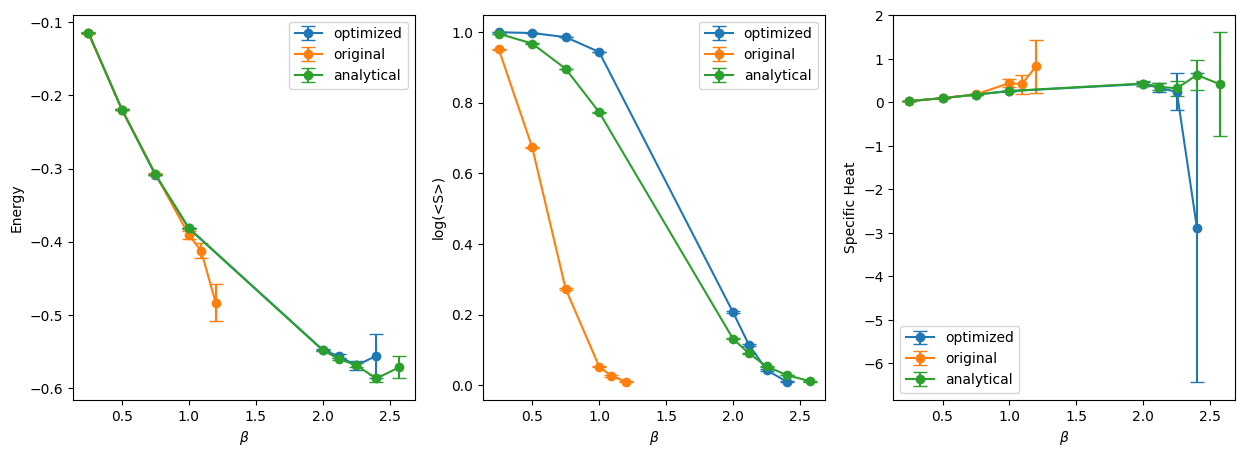

In [5]:
J1 = 0.7
J2 = 0

_df = df[(df.J1 == J1) & (df.J2 == J2) & (df["n_sites"] == 64)]

dict_df = {
    "optimized": _df[(_df.u_path.notna()) & (_df.loss_func == "1_mel")].sort_values('as', ascending=False).drop_duplicates(subset=['T']),
    "original": _df[(_df.u_path.isna()) & (_df.loss_func == "1_mel")].sort_values('as', ascending=False).drop_duplicates(subset=['T']),
    "analytical": _df[(_df.u_path.isna()) & (_df.loss_func == "-1_none")].sort_values('as', ascending=False).drop_duplicates(subset=['T']),
}


for key, df_t in dict_df.items():
    mask = (df_t['as'] > 0.005) & (df_t['T'] >= 0.1)
    df_t = df_t[mask]
    # sort by T
    df_t = df_t.sort_values(by='T')
    dict_df[key] = df_t

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))  

label = f"J1={J1}, J2={J2}"

for key, df_t in dict_df.items():
    # Plot with error bars
    ax1.errorbar(1/df_t["T"], df_t["e"], yerr=df_t["e_error"], 
                fmt='o-', capsize=5, label=key)
    ax2.errorbar(1/df_t["T"], df_t["as"], yerr=df_t["as_error"],
                fmt='o-', capsize=5, label=key)
    ax3.errorbar(1/df_t["T"], df_t["c"], yerr=df_t["c_error"],
                fmt='o-', capsize=5, label=key)

ax1.legend()
ax1.set_xlabel("$\\beta$")
ax1.set_ylabel("Energy")

ax2.legend()
ax2.set_xlabel("$\\beta$")
ax2.set_ylabel("log(<S>)")

ax3.legend()
ax3.set_xlabel("$\\beta$")
ax3.set_ylabel("Specific Heat")


In [22]:
_df[(_df.loss_func == "1_mel")]

,model_name,alpha,T,bc,n_sites,u_path,ham_path,sweeps,as,as_error,...,m,m_error,chi,chi_error,loss_func,init_loss,loss,J0,J1,J2
38,SS2D,0.1,1.0,obc,64,NaN,/home/keisuke/worms/python/rmsKit/array/torch/...,999936,0.051265,0.001725,...,0.0,0.0,0.0,0.0,1_mel,0.256262,NaN,1.0,0.7,0.0
45,SS2D,0.1,1.0,obc,64,NaN,/home/keisuke/worms/python/rmsKit/array/torch/...,999936,0.050993,0.001539,...,0.0,0.0,0.0,0.0,1_mel,0.256262,NaN,1.0,0.7,0.0
49,SS2D,0.1,1.0,obc,16,NaN,/home/keisuke/worms/python/rmsKit/array/torch/...,999936,0.571955,0.002394,...,0.0,0.0,0.0,0.0,1_mel,0.256262,NaN,1.0,0.7,0.0
50,SS2D,0.1,1.0,obc,36,NaN,/home/keisuke/worms/python/rmsKit/array/torch/...,999936,0.217488,0.002033,...,0.0,0.0,0.0,0.0,1_mel,0.256262,NaN,1.0,0.7,0.0
51,SS2D,0.1,1.0,obc,64,NaN,/home/keisuke/worms/python/rmsKit/array/torch/...,999936,0.051681,0.001595,...,0.0,0.0,0.0,0.0,1_mel,0.256262,NaN,1.0,0.7,0.0
52,SS2D,0.1,1.0,obc,100,NaN,/home/keisuke/worms/python/rmsKit/array/torch/...,999936,0.008389,0.001369,...,0.0,0.0,0.0,0.0,1_mel,0.256262,NaN,1.0,0.7,0.0
53,SS2D,0.1,1.0,obc,32,NaN,/home/keisuke/worms/python/rmsKit/array/torch/...,999936,0.275582,0.002190,...,0.0,0.0,0.0,0.0,1_mel,0.256262,NaN,1.0,0.7,0.0
54,SS2D,0.1,1.0,obc,32,NaN,/home/keisuke/worms/python/rmsKit/array/torch/...,999936,0.274264,0.002012,...,0.0,0.0,0.0,0.0,1_mel,0.256262,NaN,1.0,0.7,0.0
55,SS2D,0.1,1.0,obc,32,NaN,/home/keisuke/worms/python/rmsKit/array/torch/...,999936,0.274860,0.002156,...,0.0,0.0,0.0,0.0,1_mel,0.256262,NaN,1.0,0.7,0.0
56,SS2D,0.1,1.0,obc,40,NaN,/home/keisuke/worms/python/rmsKit/array/torch/...,999936,0.188196,0.002068,...,0.0,0.0,0.0,0.0,1_mel,0.256262,NaN,1.0,0.7,0.0


Text(0, 0.5, 'Specific Heat')

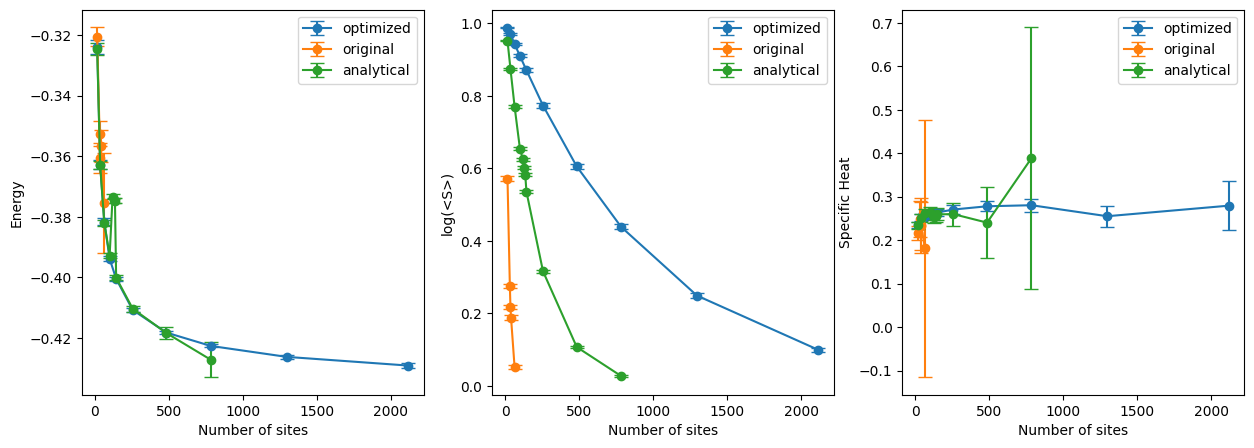

In [15]:
J1 = 0.7
J2 = 0

_df = df[(df.J1 == J1) & (df.J2 == J2) & (df["T"] == 1)]

dict_df = {
    "optimized": _df[(_df.u_path.notna()) & (_df.loss_func == "1_mel")].drop_duplicates(subset=['n_sites']),
    "original": _df[(_df.u_path.isna()) & (_df.loss_func == "1_mel")].drop_duplicates(subset=['n_sites']),
    "analytical": _df[(_df.u_path.isna()) & (_df.loss_func == "-1_none")].drop_duplicates(subset=['n_sites']),
}

for key, df_t in dict_df.items():
    mask = (df_t['as'] > 0.01)
    df_t = df_t[mask]
    # sort by n_sites
    df_t = df_t.sort_values(by='n_sites')
    dict_df[key] = df_t

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))  

label = f"J1={J1}, J2={J2}"

for key, df_t in dict_df.items():
    # Plot with error bars
    ax1.errorbar(df_t["n_sites"], df_t["e"], yerr=df_t["e_error"] * 3, 
                fmt='o-', capsize=5, label=key)
    ax2.errorbar(df_t["n_sites"], df_t["as"], yerr=df_t["as_error"] * 3,
                fmt='o-', capsize=5, label=key)
    ax3.errorbar(df_t["n_sites"], df_t["c"], yerr=df_t["c_error"] * 3,
                fmt='o-', capsize=5, label=key)

ax1.legend()
ax1.set_xlabel("Number of sites")
ax1.set_ylabel("Energy")

ax2.legend()
ax2.set_xlabel("Number of sites")
ax2.set_ylabel("log(<S>)")

ax3.legend()
ax3.set_xlabel("Number of sites")
ax3.set_ylabel("Specific Heat")


Index(['model_name', 'alpha', 'temperature', 'bc', 'n_sites', 'u_path',
       'ham_path', 'sweeps', 'as', 'as_error', 'e', 'e_error', 'c', 'c_error',
       'm', 'm_error', 'chi', 'chi_error', 'loss_func', 'loss', 'init_loss',
       'J1', 'J2', 'J3'],
      dtype='object')